In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

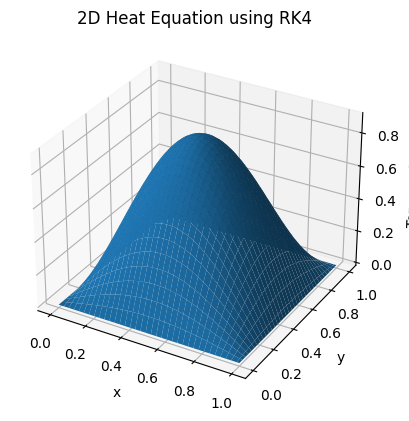

In [3]:
lx=1
ly=1
steps=100
#no of points along x,y direc
nx=70
ny=70

# spacing between points along x,y direc
dx=lx/(nx-1)
dy=ly/(ny-1)

#stability cond
dt=0.25*min(dx**2,dy**2)     ##cant und the command given in step 8

#setting x,y
x=np.linspace(0,1,nx)
y=np.linspace(0,1,ny)
X,Y=np.meshgrid(x,y)

#initial condn
u=np.sin(np.pi*X)*np.sin(np.pi*Y)

#Computing laplacing to represent time
def laplacian(u):
    dudt=np.zeros_like(u)
    for i in range(1,nx-1):
        for j in range(1,ny-1):
            de2udx2=(u[i+1,j]-2*u[i,j]+u[i-1,j])/dx**2
            de2dy2=(u[i,j+1]-2*u[i,j]+u[i,j-1])/dy**2
            dudt[i,j]=de2udx2+de2dy2
    return dudt
    
for k in range(steps):
    k1=laplacian(u)
    k2=laplacian(u+0.5*dt*k1)
    k3=laplacian(u+dt*k2*0.5)
    k4=laplacian(u+dt*k3)
    u=u+(dt/6)*(k1+2*k2+2*k3+k4)
    #setting boundary condns #our edges kept at zero
    u[0,:]=0
    u[-1,:]=0
    u[:,0]=0
    u[:,-1]=0

##3d plotting for visualization from chatgpt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y, u)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Temperature")

ax.set_title("2D Heat Equation using RK4")

plt.show()


    

r = 0.004802000000000002


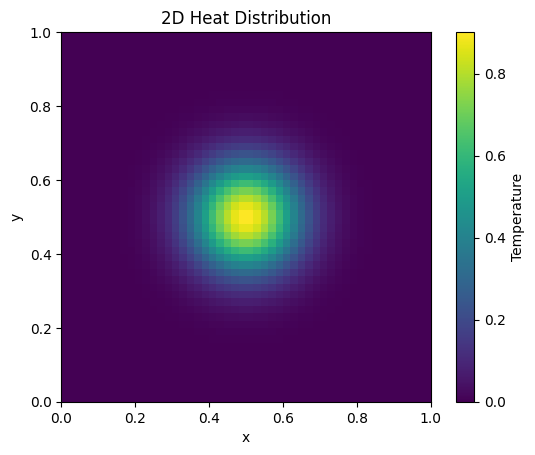

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
Lx = 1.0
Ly = 1.0

nx = 50
ny = 50

dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

alpha = 0.01
dt = 0.0001
nt = 500

# Stability condition
r = alpha * dt * (1/dx**2 + 1/dy**2)
print("r =", r)

if r > 0.5:
    print("Warning: unstable!")

# ----------------------------
# Grid
# ----------------------------
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)

# ----------------------------
# Initial condition
# ----------------------------
u = np.zeros((nx, ny))

# Gaussian bump in center
for i in range(nx):
    for j in range(ny):
        u[i,j] = np.exp(-50*((x[i]-0.5)**2 + (y[j]-0.5)**2))

# ----------------------------
# Time evolution
# ----------------------------
for n in range(nt):
    u_new = u.copy()
    
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            u_new[i,j] = u[i,j] + alpha*dt*(
                (u[i+1,j] - 2*u[i,j] + u[i-1,j]) / dx**2 +
                (u[i,j+1] - 2*u[i,j] + u[i,j-1]) / dy**2
            )
    
    # Boundary conditions (fixed = 0)
    u_new[0,:] = 0
    u_new[-1,:] = 0
    u_new[:,0] = 0
    u_new[:,-1] = 0
    
    u = u_new

# ----------------------------
# Plot result
# ----------------------------
plt.imshow(u, extent=[0,1,0,1])
plt.colorbar(label="Temperature")
plt.title("2D Heat Distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

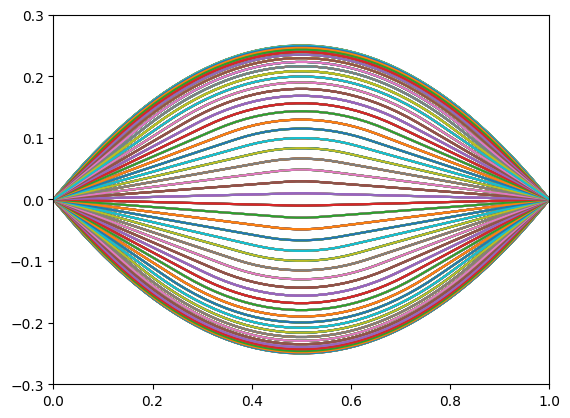

In [6]:
#Vibration of string fixed at two ends
#del**2u/delt**2=c**2*del**2u/delx**2


import numpy as np
import matplotlib.pyplot as plt


l=1                           #Length of string
n=50                         #Equidistant points on string
x=np.linspace(0,1,n)


u=np.zeros((3,n))
u[0]=x*(l-x)
c2=1


for i in range(1,n-1):
    u[1,i]=u[0,i]+0.5*c2*(u[0,i+1]+u[0,i-1]-2*u[0,i])
for t in range(500):
    for i in range(1,n-1):
        u[2,i]=2*u[1,i]-u[0,i]+c2*(u[1,i+1]+u[1,i-1]-2*u[1,i])


    u[0]=u[1]
    u[1]=u[2]


#For plotting    
    plt.plot(x,u[2])
    plt.ylim(-0.3,0.3)
    plt.xlim(0,1)
